<a href="https://colab.research.google.com/github/Mou9tafa/Google-play-app-analysis/blob/main/code/python_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/coderz/googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.shape

(10841, 13)

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df["Reviews"]=df["Reviews"].str.replace("M","").astype(float)

In [ ]:
df["Installs"].mode()

,Installs
0,"1,000,000+"


In [ ]:
if df['Installs'].dtype == 'object':
    df['Installs']=df['Installs'].str.replace("+","")
    df['Installs']=df['Installs'].str.replace(",","")
    df['Installs']=df['Installs'].str.replace("Free","1000000")


df['Installs']=df['Installs'].astype(float)

In [ ]:
count = (df["Price"] == "Everyone").sum()
print(count)

1


In [ ]:
df['Price'].mode()

,Price
0,0


In [ ]:
if df['Price'].dtype == 'object':
    df['Price']=df['Price'].str.replace("Everyone","0")
    df['Price']=df['Price'].str.replace("$","0")



df['Price']=df['Price'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  float64
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(4), object(9)
memory usage: 1.1+ MB


<Axes: >

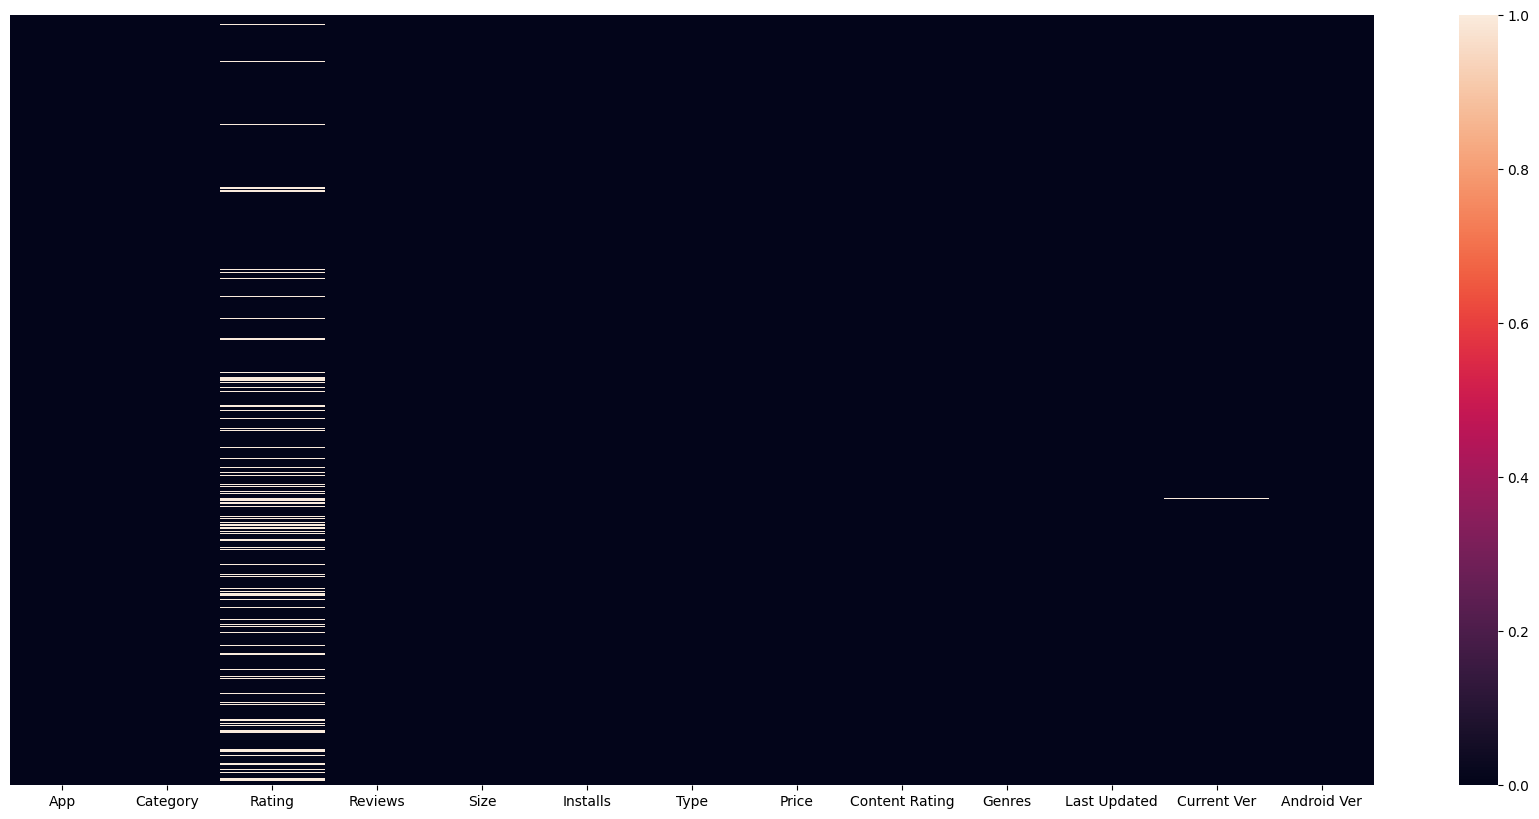

In [ ]:
plt.figure(figsize=(22,10))
sns.heatmap(df.isnull(),yticklabels=False)

In [ ]:
df.describe()

,Rating,Reviews,Installs,Price
count,9367.000000,1.084100e+04,1.084100e+04,10841.000000
mean,4.193338,4.441119e+05,1.546300e+07,1.027273
std,0.537431,2.927629e+06,8.502555e+07,15.948971
min,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,0.000000
50%,4.300000,2.094000e+03,1.000000e+05,0.000000
75%,4.500000,5.476800e+04,5.000000e+06,0.000000
max,19.000000,7.815831e+07,1.000000e+09,400.000000


In [ ]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

<Axes: >

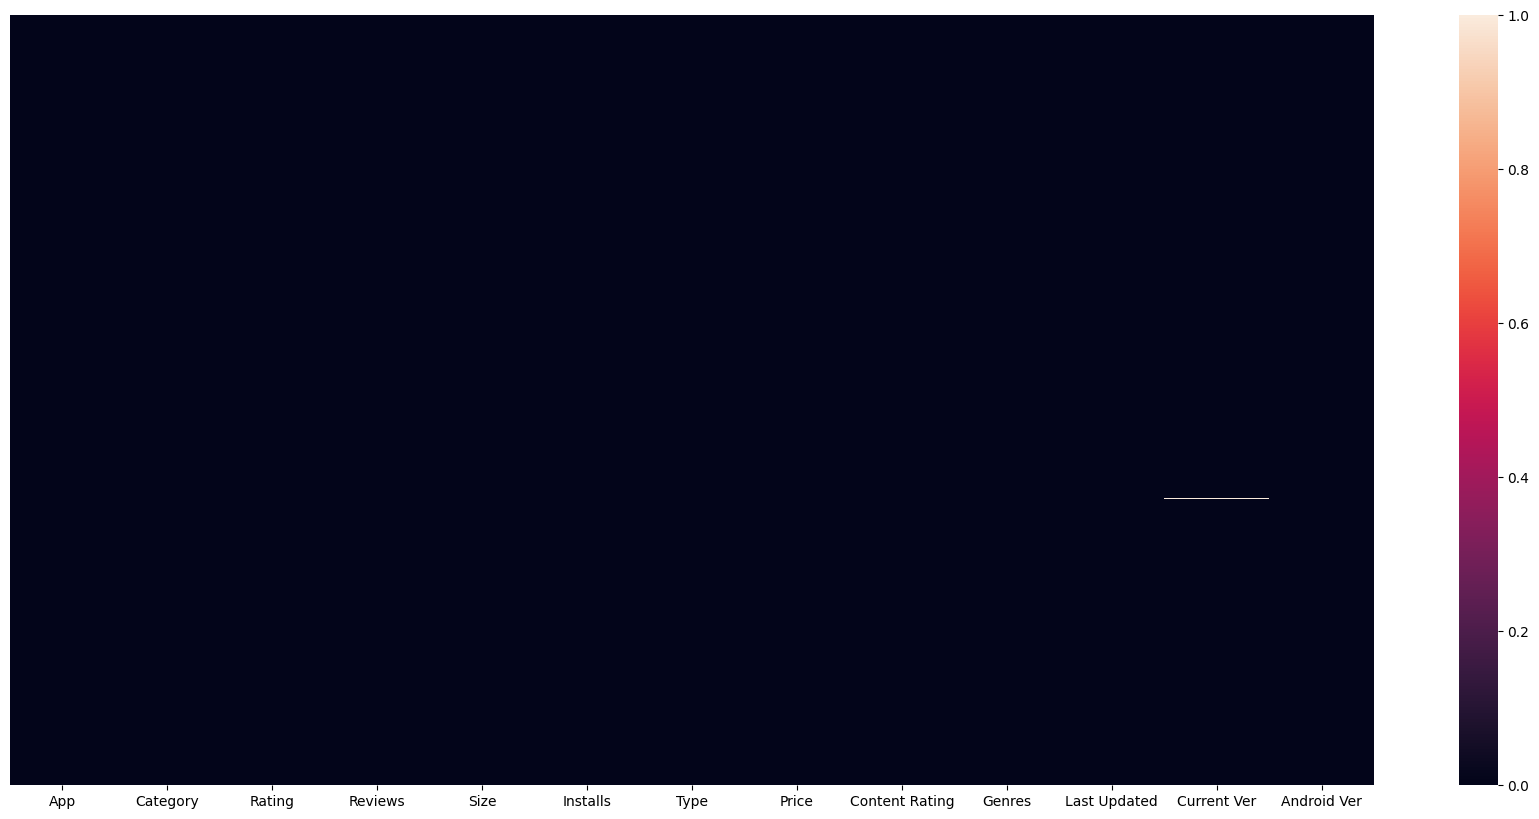

In [ ]:
plt.figure(figsize=(22,10))
sns.heatmap(df.isnull(),yticklabels=False)

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df.describe(include="object")

,App,Category,Size,Type,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10840,10840,10841,10841,10833,10838
unique,9660,34,462,3,6,120,1378,2832,33
top,ROBLOX,FAMILY,Varies with device,Free,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,1695,10039,8714,842,326,1459,2451


In [ ]:
df["Content Rating"] = df["Content Rating"].fillna(df["Content Rating"].mode()[0])

In [ ]:
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])

In [ ]:
df["Current Ver"] = df["Current Ver"].fillna(df["Current Ver"].mode()[0])

In [ ]:
df["Android Ver"] = df["Android Ver"].fillna(df["Android Ver"].mode()[0])

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


<Axes: >

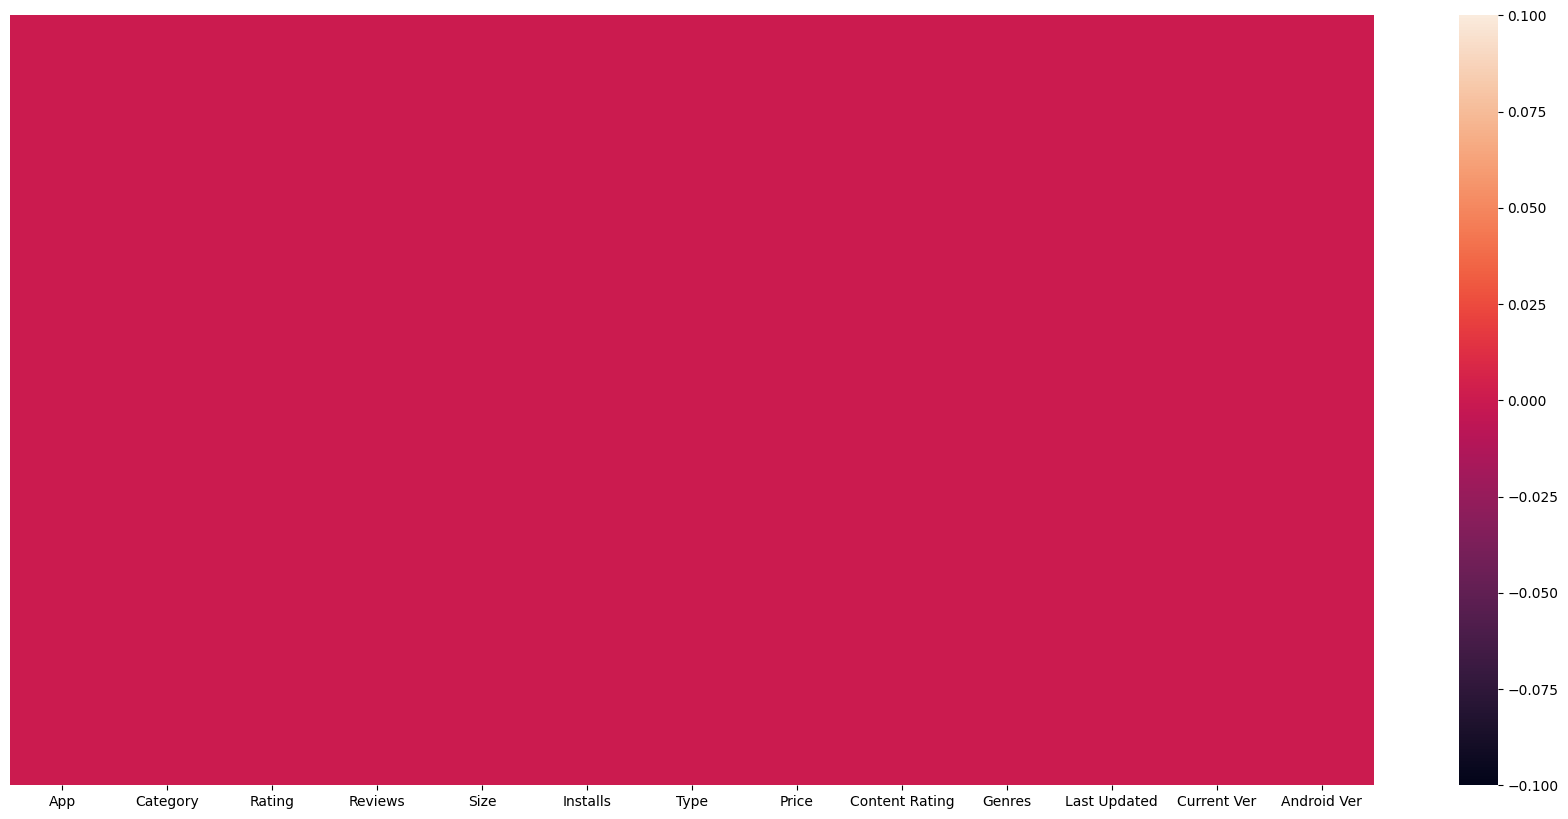

In [ ]:
plt.figure(figsize=(22,10))
sns.heatmap(df.isnull(),yticklabels=False)

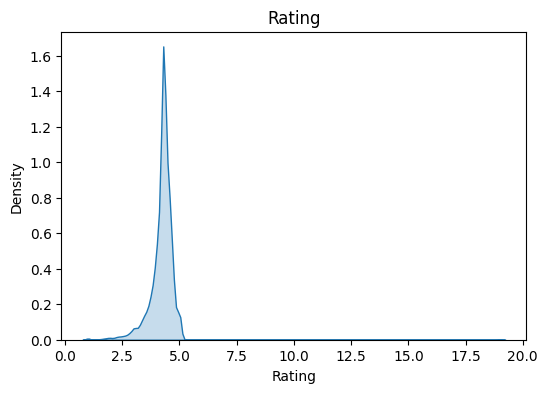

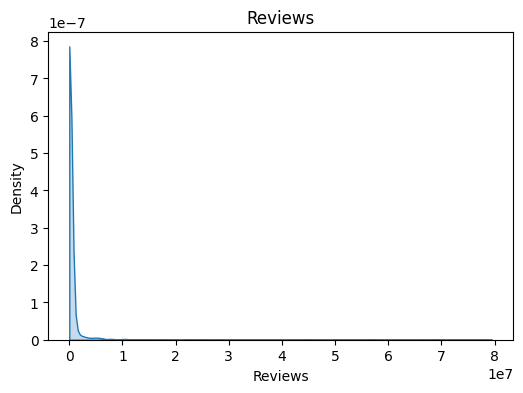

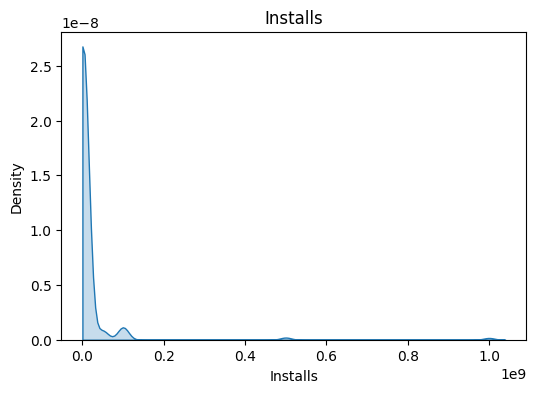

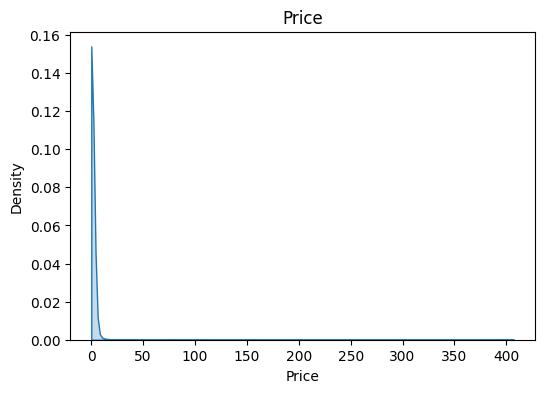

In [ ]:

cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in cols:
    plt.figure(figsize=(6,4))

    sns.kdeplot(df[col], fill=True, clip=(0, None))

    plt.title(col)
    plt.show()

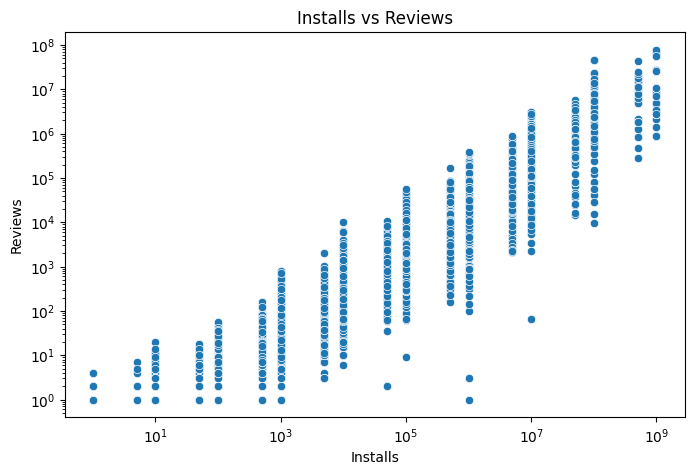

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Installs', y='Reviews', data=df)
plt.xscale('log')
plt.yscale('log')
plt.title("Installs vs Reviews")
plt.show()

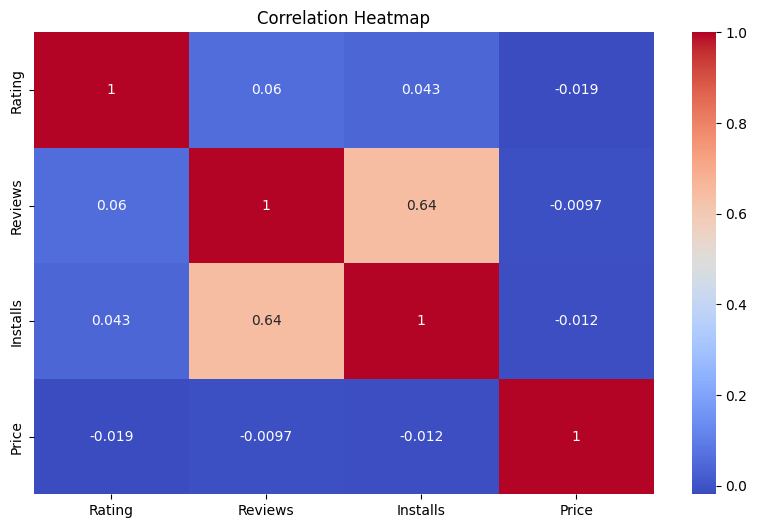

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

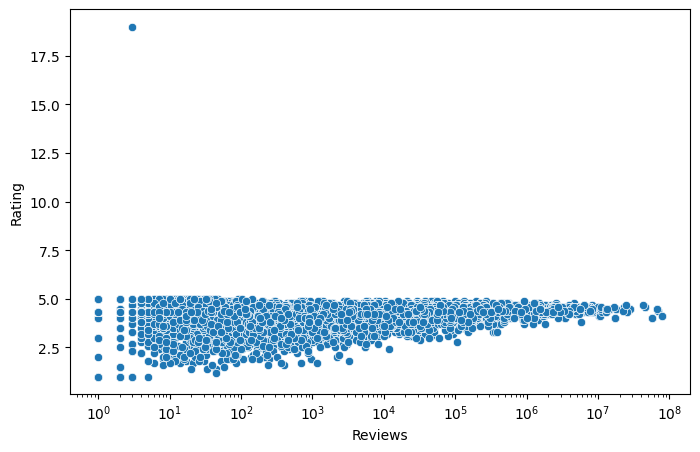

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.xscale('log')
plt.show()

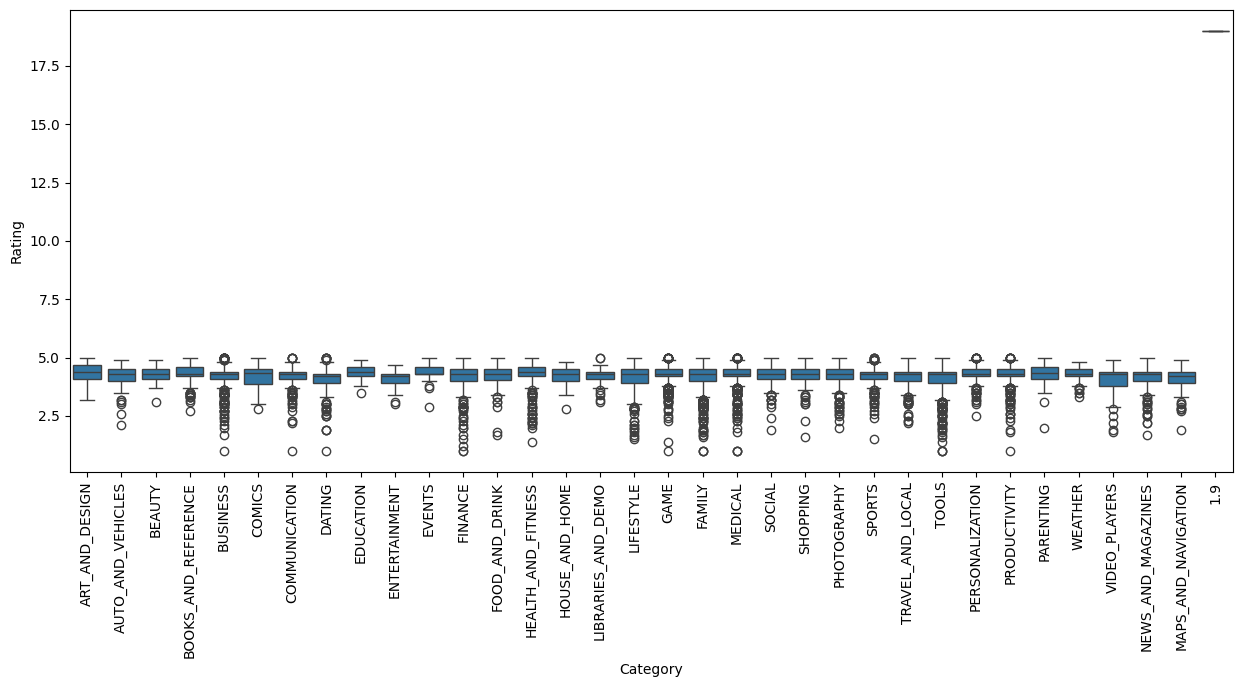

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Category', y='Rating', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
top5_categories = (
    df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(5))
print(top5_categories)

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.388462
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.335498
Name: Rating, dtype: float64


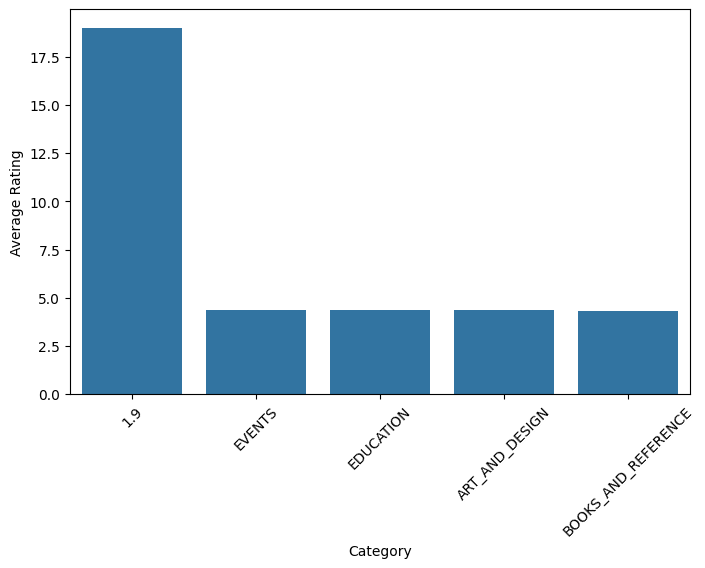

In [ ]:
top5_categories = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top5_categories.index,
    y=top5_categories.values
)
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.xlabel("Category")
plt.show()

In [ ]:
df.loc[df["Rating"].idxmax(), "App"]

'Life Made WI-Fi Touchscreen Photo Frame'

In [ ]:
df.loc[df["App"] == "Life Made WI-Fi Touchscreen Photo Frame", "Rating"]

,Rating
10472,19.0


In [ ]:
df.drop(df[df["Category"].astype(str) == "1.9"].index, inplace=True)

In [ ]:
top5_categories = (
    df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(5))
print(top5_categories)

Category
EVENTS                 4.395313
EDUCATION              4.388462
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.335498
PERSONALIZATION        4.328827
Name: Rating, dtype: float64


In [ ]:
df.loc[df["Rating"].idxmax(), "App"]

'Hojiboy Tojiboyev Life Hacks'

In [ ]:
df.loc[df["App"] == "Hojiboy Tojiboyev Life Hacks"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
329,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,15.0,37M,1000.0,Free,0.0,Everyone,Comics,"June 26, 2018",2.0,4.0.3 and up


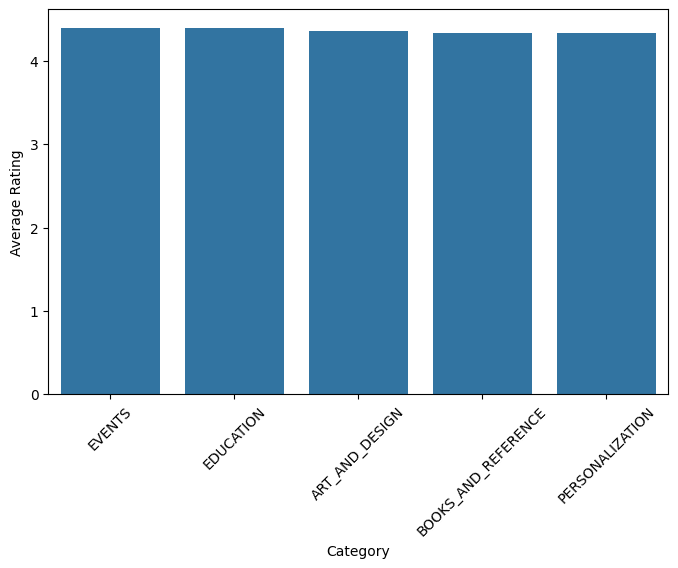

In [ ]:
top5_categories = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top5_categories.index,
    y=top5_categories.values
)
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.xlabel("Category")
plt.show()